In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
!pip install openpyxl
warnings.filterwarnings('ignore')


In [110]:
from google.colab import drive, files
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Proyecto-IA/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
from pandas.core.reshape import encoding
df = pd.read_excel("/content/drive/MyDrive/Proyecto-IA/2022Banca/inclusion_financiera.xlsx")


In [112]:
df.columns = df.columns.str.strip().str.upper()
print(df.columns)
df.head()





Index(['T101_1', 'T101_2', 'T101_3', 'T101_4', 'T101_5', 'T101_6', 'T101_7',
       'T101_8', 'CT101_9_COD', 'T101_9_COD',
       ...
       'DANE', 'CIUDAD', 'REGION', 'TIPO_MUNI', 'EDADR', 'ESTRATOIMP',
       'REGIÓN', 'RURALIDAD', 'FEXP_MPIO', 'FEXP_REG_RUR'],
      dtype='object', length=432)


,T101_1,T101_2,T101_3,T101_4,T101_5,T101_6,T101_7,T101_8,CT101_9_COD,T101_9_COD,...,DANE,CIUDAD,REGION,TIPO_MUNI,EDADR,ESTRATOIMP,REGIÓN,RURALIDAD,FEXP_MPIO,FEXP_REG_RUR
0,NO,NO,NO,NO,NO,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad26_35,Estrato_1,Eje cafetero,Ciudades y aglomerac,4640.554069,11449.997030
1,NO,NO,NO,NO,SÍ,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad46_55,Estrato_1,Eje cafetero,Ciudades y aglomerac,1631.018350,4024.337394
2,NO,SÍ,NO,NO,NO,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad56_o_mas,Estrato_1,Eje cafetero,Ciudades y aglomerac,4202.534068,10369.236490
3,NO,NO,NO,NO,NO,NO,NO,NO,NaN,NaN,...,11001,"Bogotá, D.C.",CENTRO ORIENTE,CIUDADES Y AGLOMERACIONES,Edad36_45,Estrato_2,Centro Oriente,Ciudades y aglomerac,4243.530937,6544.894327
4,SÍ,SÍ,NO,NO,NO,NO,NO,NO,Tarjeta de crédito,Tarjetas de credito,...,76001,Cali,PACÍFICO,CIUDADES Y AGLOMERACIONES,Edad26_35,Estrato_4,Pacífico,Ciudades y aglomerac,14843.126100,33366.724480


In [113]:
df = df.replace({98: np.nan, 99: np.nan})
df.head()

,T101_1,T101_2,T101_3,T101_4,T101_5,T101_6,T101_7,T101_8,CT101_9_COD,T101_9_COD,...,DANE,CIUDAD,REGION,TIPO_MUNI,EDADR,ESTRATOIMP,REGIÓN,RURALIDAD,FEXP_MPIO,FEXP_REG_RUR
0,NO,NO,NO,NO,NO,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad26_35,Estrato_1,Eje cafetero,Ciudades y aglomerac,4640.554069,11449.997030
1,NO,NO,NO,NO,SÍ,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad46_55,Estrato_1,Eje cafetero,Ciudades y aglomerac,1631.018350,4024.337394
2,NO,SÍ,NO,NO,NO,NO,NO,NO,NaN,NaN,...,5001,Medellín,EJE CAFETERO,CIUDADES Y AGLOMERACIONES,Edad56_o_mas,Estrato_1,Eje cafetero,Ciudades y aglomerac,4202.534068,10369.236490
3,NO,NO,NO,NO,NO,NO,NO,NO,NaN,NaN,...,11001,"Bogotá, D.C.",CENTRO ORIENTE,CIUDADES Y AGLOMERACIONES,Edad36_45,Estrato_2,Centro Oriente,Ciudades y aglomerac,4243.530937,6544.894327
4,SÍ,SÍ,NO,NO,NO,NO,NO,NO,Tarjeta de crédito,Tarjetas de credito,...,76001,Cali,PACÍFICO,CIUDADES Y AGLOMERACIONES,Edad26_35,Estrato_4,Pacífico,Ciudades y aglomerac,14843.126100,33366.724480


In [114]:
def es_binaria(col):
    valores = df[col].dropna().astype(str).str.strip().str.upper().unique()
    return set(valores).issubset({"SÍ", "SI", "NO", "NS/NR (E: NO LEER)"})

cols_billetera_limpias = [col for col in cols_billetera if es_binaria(col)]

df_billetera = df[cols_billetera_limpias].applymap(
    lambda x: 1 if str(x).strip().upper() in ["SÍ", "SI"] else 0
)

df["billetera_digital"] = df_billetera.max(axis=1)
df["billetera_digital"].value_counts()

,count
billetera_digital,
1,3388
0,2222


In [115]:
cols_inclusion = ["T202_1", "T202_2", "T202_3", "T202_4"]

df_inclusion = df[cols_inclusion].applymap(
    lambda x: 1 if str(x).strip().upper() in ["SÍ", "SI"] else 0
)

df["inclusion_financiera"] = df_inclusion.max(axis=1)
df["inclusion_financiera"].value_counts()

,count
inclusion_financiera,
1,4738
0,872


In [116]:
df_final = df[["EDAD", "GENERO", "P705", "P709", "RURALIDAD", "ESTRATO", "REGION"]].copy()
df_final.head()

,EDAD,GENERO,P705,P709,RURALIDAD,ESTRATO,REGION
0,35,Femenino,NaN,Dos o más,Ciudades y aglomerac,1,EJE CAFETERO
1,48,Femenino,NaN,Ninguno,Ciudades y aglomerac,1,EJE CAFETERO
2,69,Femenino,NaN,Uno,Ciudades y aglomerac,1,EJE CAFETERO
3,41,Femenino,NaN,Uno,Ciudades y aglomerac,NS/NR (E: No leer),CENTRO ORIENTE
4,32,Femenino,NaN,Dos o más,Ciudades y aglomerac,4,PACÍFICO


In [117]:
df_final = df_final.rename(columns={"EDAD": "Edad", "GENERO": "Sexo", "P705": "Trabajo", "P709": "Ingreso", "RURALIDAD": "Zona", "ESTRATO": "Estrato", "REGION": "Region"})
df_final.head()

,Edad,Sexo,Trabajo,Ingreso,Zona,Estrato,Region
0,35,Femenino,NaN,Dos o más,Ciudades y aglomerac,1,EJE CAFETERO
1,48,Femenino,NaN,Ninguno,Ciudades y aglomerac,1,EJE CAFETERO
2,69,Femenino,NaN,Uno,Ciudades y aglomerac,1,EJE CAFETERO
3,41,Femenino,NaN,Uno,Ciudades y aglomerac,NS/NR (E: No leer),CENTRO ORIENTE
4,32,Femenino,NaN,Dos o más,Ciudades y aglomerac,4,PACÍFICO


In [118]:
df_final["Billetera_Digital"] = df["billetera_digital"]
df_final["Inclusion_Financiera"] = df["inclusion_financiera"]
df_final.head()

,Edad,Sexo,Trabajo,Ingreso,Zona,Estrato,Region,Billetera_Digital,Inclusion_Financiera
0,35,Femenino,NaN,Dos o más,Ciudades y aglomerac,1,EJE CAFETERO,0,1
1,48,Femenino,NaN,Ninguno,Ciudades y aglomerac,1,EJE CAFETERO,1,1
2,69,Femenino,NaN,Uno,Ciudades y aglomerac,1,EJE CAFETERO,0,0
3,41,Femenino,NaN,Uno,Ciudades y aglomerac,NS/NR (E: No leer),CENTRO ORIENTE,0,1
4,32,Femenino,NaN,Dos o más,Ciudades y aglomerac,4,PACÍFICO,1,1


In [119]:
df_final = df_final.dropna()
df_final = df_final.reset_index(drop=True)
df_final.head()

,Edad,Sexo,Trabajo,Ingreso,Zona,Estrato,Region,Billetera_Digital,Inclusion_Financiera
0,60,Masculino,Trabajador(a) por cuenta propia (no contrata t...,Dos o más,Ciudades y aglomerac,3,PACÍFICO,1,1
1,46,Masculino,Trabajador(a) por cuenta propia (no contrata t...,Ninguno,Ciudades y aglomerac,No tiene,EJE CAFETERO,1,0
2,20,Masculino,Empleado(a) u obrero(a),Dos o más,Ciudades y aglomerac,1,EJE CAFETERO,1,1
3,62,Femenino,Trabajador(a) sin pago,Uno,Ciudades y aglomerac,1,EJE CAFETERO,0,1
4,23,Femenino,Empleado(a) u obrero(a),Dos o más,Ciudades y aglomerac,2,CENTRO ORIENTE,1,1


In [120]:
pd.crosstab(
    df_final["Billetera_Digital"],
    df_final["Inclusion_Financiera"],
    normalize="index"
)

Inclusion_Financiera,0,1
Billetera_Digital,,
0,0.221831,0.778169
1,0.046059,0.953941


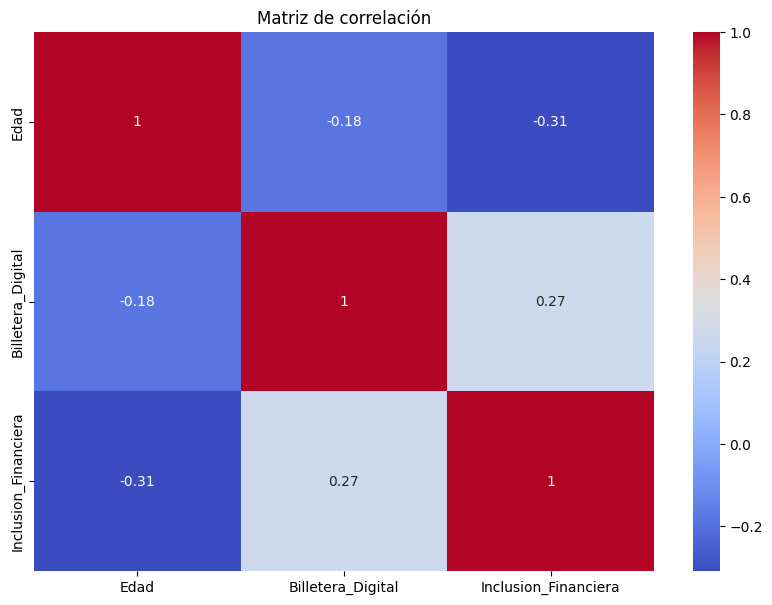

In [121]:
plt.figure(figsize=(10,7))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

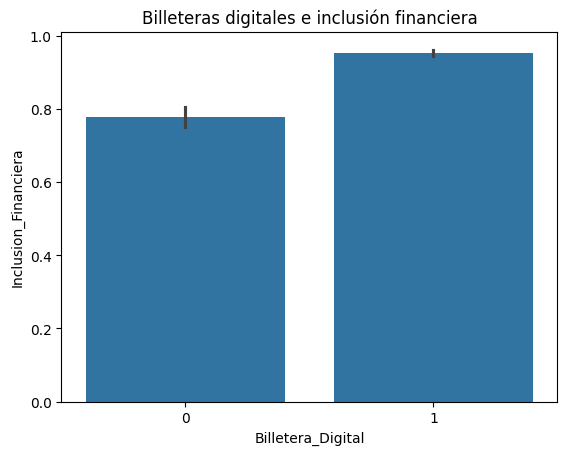

In [122]:
sns.barplot(
    x="Billetera_Digital",
    y="Inclusion_Financiera",
    data=df_final
)
plt.title("Billeteras digitales e inclusión financiera")
plt.show()

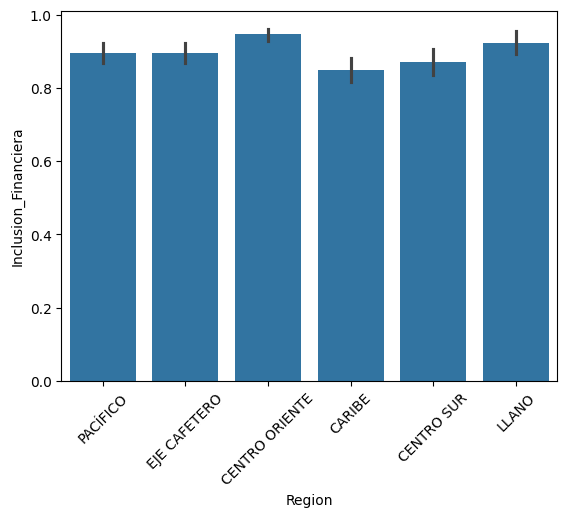

In [123]:
sns.barplot(
    x="Region",
    y="Inclusion_Financiera",
    data=df_final
)
plt.xticks(rotation=45)
plt.show()

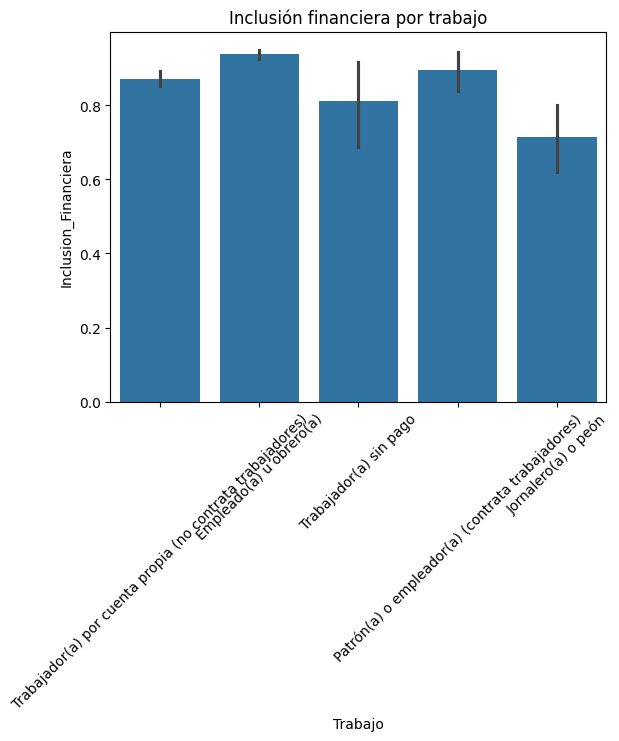

In [125]:
sns.barplot(
    x="Trabajo",
    y="Inclusion_Financiera",
    data=df_final
)

plt.xticks(rotation=45)
plt.title("Inclusión financiera por trabajo")
plt.show()